# 03 — User-Based KNN e comparação final
**Laboratório de Estatística Aplicada — 2026/2 | Victor Coscrato**  
**Isabella Viana Bambirra**

Notebook independente, com leitura dos dados e funções compartilhadas. Metadados entram apenas na apresentação dos títulos.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
from projeto import *
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.spines.top': False, 'axes.spines.right': False})
ratings, users, items = load_data()
display(versions())
kind = 'KNN'

{'python': '3.12.14',
 'numpy': '1.26.4',
 'pandas': '3.0.6',
 'matplotlib': '3.11.2',
 'scikit-learn': '1.9.1',
 'scikit-surprise': '1.1.5',
 'nbformat': '5.11.1',
 'nbclient': '0.11.0',
 'ipykernel': '7.4.0'}

## 1. Vizinhanças de usuários
Páginas 20–21: usuários com avaliações parecidas podem ajudar a estimar preferências uns dos outros. A similaridade cosseno compara a direção dos vetores:

$$sim(u,v)=\frac{R_u\cdot R_v}{\|R_u\|\|R_v\|}.$$

Na Surprise, o cosseno é calculado **somente nas avaliações de filmes comuns ao par**, sem preencher notas ausentes com zero. Se o suporte comum é menor que `min_support`, a similaridade é zero. A diagonal tem similaridade 1.

A formulação apresentada na aula é:

$$\hat r_{ui}=\frac{\sum_{v\in N_i(u)}sim(u,v)r_{vi}}{\sum_{v\in N_i(u)}|sim(u,v)|}.$$

Os candidatos a vizinhos precisam ter avaliado **aquele filme**. `KNNBasic(user_based=True, cosine)` escolhe até `k` deles e agrega somente similaridades positivas. Com pesos positivos, o denominador coincide com a soma dos módulos. Com notas de 1 a 5, os cossenos com suporte são positivos; pesos negativos não surgem nesta configuração. A regra de descartar similaridades não positivas é um detalhe geral da biblioteca, não uma diferença numérica causada por pesos negativos neste experimento.

`k` é o máximo, não uma garantia: `actual_k` registra quantos vizinhos positivos contribuíram. `min_k` define o mínimo efetivo; abaixo dele, ou diante de usuário/filme desconhecido, a previsão é considerada impossível e a Surprise usa a **média global do treino**, limitada à escala. `min_support` exige avaliações em comum para calcular a similaridade. Como notas são positivas, cossenos de pares com suporte podem ser altos até com pouco histórico: aumentar suporte ajuda a evitar semelhanças apoiadas em um único filme.

A grade testa (k,min_k,min_support) = (40,1,1), (20,3,3), (60,3,3). Mantemos a identidade User-Based/cosseno. Não adicionamos KNNWithMeans: a comparação pedida já permite estudar vizinhança e fatores sem ampliar o escopo.

In [2]:
display(pd.DataFrame(CONFIGS[kind]).rename_axis('configuração'))
print(manual_checks())

,k,min_k,min_support
configuração,,,
0,40,1,1
1,20,3,3
2,60,3,3


RMSE manual = √2,5; Precisão@10 manual = 2/10; cold start conferido.


## Protocolo comum: prever notas e recomendar listas
Usamos **5 folds externos** de avaliações, embaralhados com semente 2026: 80 mil notas no treino e 20 mil no teste. Os mesmos índices são gravados em `data/splits/`. Todos os modelos recebem exatamente esses conjuntos. A divisão aleatória mede recuperação de avaliações ocultadas de usuários existentes; não simula integralmente recomendar filmes futuros.

O ajuste usa uma única divisão interna 80/20 dentro de cada treino externo, semente 2026 + fold. Cada algoritmo testa somente três configurações. Selecionamos o **menor RMSE interno**, com desempate pela ordem da grade. Portanto, o ajuste não foi otimizado para Precisão@10. O teste externo nunca escolhe parâmetros. A configuração inicial também é avaliada, mas as conclusões usam a ajustada.

**RMSE**: $\sqrt{\frac{1}{n}\sum_{(u,i)\in teste}(r_{ui}-\hat r_{ui})^2}$. Penaliza mais erros grandes e está na escala das notas. O baseline prevê a média global do treino; contagens de popularidade não são notas.

**Precisão@10**: $|Top10_u\cap Relevantes_u|/10$, com nota real **≥ 4 no teste** como decisão operacional. Usuário elegível precisa de histórico no treino, pelo menos dez filmes candidatos e pelo menos um relevante elegível. Candidatos são todos os filmes presentes no treino, exceto os avaliados por aquela pessoa no treino. Empates de escores são resolvidos pelo menor ID. Nenhum corte de nota prevista encurta a lista.

Os três métodos usam os mesmos candidatos e usuários. A popularidade ordena contagens de treino. Filmes sem avaliação no teste não são acertos, embora sua relevância seja desconhecida: esta é uma avaliação offline incompleta e condicionada às preferências observadas. Não é uma estimativa sem viés da precisão em uso real: a ausência de notas reduz os acertos observáveis, mas a seleção dos filmes avaliados e dos usuários elegíveis pode favorecer alguns métodos. Exclusões por usuário e motivo são salvas. RMSE inclui todo o teste, inclusive casos de filme desconhecido; Precisão@10 exclui filmes fora do catálogo de treino.

Médias e desvios-padrão amostrais resumem os cinco folds. Esses folds compartilham treinos; diferenças médias e barras de desvio não estabelecem superioridade estatística.

In [3]:
metrics = evaluate(kind,ratings)
display(metrics)

KNN fold 1


KNN fold 2


KNN fold 3


KNN fold 4


KNN fold 5


,fold,model,variant,rmse,precision10,n_users,fit_seconds,evaluation_seconds,fallback_test,fallback_candidates,unknown_users,unknown_items,params
0,1,KNN,inicial,1.021086,0.000538,929,0.301086,5.020728,0.00205,0.002460,0,41,"{""k"": 40, ""min_k"": 1, ""min_support"": 1}"
1,1,KNN,ajustado,1.017550,0.071259,929,0.288346,5.159019,0.00700,0.162561,0,41,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}"
2,2,KNN,inicial,1.008692,0.000000,925,0.290977,5.455986,0.00190,0.001921,0,38,"{""k"": 40, ""min_k"": 1, ""min_support"": 1}"
3,2,KNN,ajustado,1.005861,0.072757,925,0.416373,5.963366,0.00515,0.154710,0,38,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}"
4,3,KNN,inicial,1.019036,0.000326,921,0.361049,5.352697,0.00170,0.002558,0,34,"{""k"": 40, ""min_k"": 1, ""min_support"": 1}"
5,3,KNN,ajustado,1.016665,0.046037,921,0.292498,5.149076,0.00665,0.167282,0,34,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}"
6,4,KNN,inicial,1.012616,0.000430,930,0.346785,5.329025,0.00155,0.002990,0,31,"{""k"": 40, ""min_k"": 1, ""min_support"": 1}"
7,4,KNN,ajustado,1.008908,0.075699,930,0.294115,5.238113,0.00755,0.170501,0,31,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}"
8,5,KNN,inicial,1.022070,0.016143,923,0.340518,5.243053,0.00200,0.002037,0,40,"{""k"": 40, ""min_k"": 1, ""min_support"": 1}"
9,5,KNN,ajustado,1.020317,0.071723,923,0.271412,5.168706,0.00770,0.167909,0,40,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}"


## 2. Ajuste interno e resultados externos
A tabela seguinte identifica qual configuração venceu dentro de cada treino. O RMSE interno seleciona; o externo avalia. Tempos de treino excluem a busca, cujo custo está na tabela de ajuste. Avaliação inclui notas, candidatos, ordenação e verificações do processamento em lote. Medidas de tempo variam entre máquinas.

In [4]:
tuning = pd.read_csv(TABLES/f'{kind}_tuning.csv')
display(tuning)
display(tuning.loc[tuning.groupby('fold').inner_rmse.idxmin()])
summary = metrics.groupby('variant').agg(rmse_mean=('rmse','mean'),rmse_sd=('rmse','std'),precision10_mean=('precision10','mean'),precision10_sd=('precision10','std'))
display(save(summary.reset_index(),kind+'_variant_summary'))

,fold,model,configuration,params,inner_rmse,seconds
0,1,KNN,0,"{""k"": 40, ""min_k"": 1, ""min_support"": 1}",1.033539,1.387217
1,1,KNN,1,"{""k"": 20, ""min_k"": 3, ""min_support"": 3}",1.033675,1.146478
2,1,KNN,2,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}",1.028383,1.423065
3,2,KNN,0,"{""k"": 40, ""min_k"": 1, ""min_support"": 1}",1.028527,1.259040
4,2,KNN,1,"{""k"": 20, ""min_k"": 3, ""min_support"": 3}",1.030786,1.266097
5,2,KNN,2,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}",1.025445,1.380983
6,3,KNN,0,"{""k"": 40, ""min_k"": 1, ""min_support"": 1}",1.027679,1.573987
7,3,KNN,1,"{""k"": 20, ""min_k"": 3, ""min_support"": 3}",1.027659,1.359347
8,3,KNN,2,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}",1.023578,1.699251
9,4,KNN,0,"{""k"": 40, ""min_k"": 1, ""min_support"": 1}",1.015603,1.523133


,fold,model,configuration,params,inner_rmse,seconds
2,1,KNN,2,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}",1.028383,1.423065
5,2,KNN,2,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}",1.025445,1.380983
8,3,KNN,2,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}",1.023578,1.699251
11,4,KNN,2,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}",1.015164,1.480864
14,5,KNN,2,"{""k"": 60, ""min_k"": 3, ""min_support"": 3}",1.015888,1.419310


,variant,rmse_mean,rmse_sd,precision10_mean,precision10_sd
0,ajustado,1.01386,0.006158,0.067495,0.012119
1,inicial,1.01670,0.005795,0.003487,0.007078


In [5]:
adjusted = summary.loc['ajustado']; initial = summary.loc['inicial']
display(Markdown(f"A configuração inicial teve RMSE médio **{initial.rmse_mean:.4f}**, e o procedimento ajustado teve **{adjusted.rmse_mean:.4f}**. A Precisão@10 ajustada foi **{adjusted.precision10_mean:.4f}** (desvio entre folds **{adjusted.precision10_sd:.4f}**). Em média, isso equivale a **{10*adjusted.precision10_mean:.3f}** acertos observados por lista de dez. O ajuste por RMSE não garante avanço na precisão das listas."))

A configuração inicial teve RMSE médio **1.0167**, e o procedimento ajustado teve **1.0139**. A Precisão@10 ajustada foi **0.0675** (desvio entre folds **0.0121**). Em média, isso equivale a **0.675** acertos observados por lista de dez. O ajuste por RMSE não garante avanço na precisão das listas.

## 3. Cobertura e exclusões
Verificamos casos que não podem entrar no ranking principal. Um filme que só apareceu no teste não pertence ao catálogo de treino; sua nota continua na avaliação RMSE, usando a regra documentada para cold start. Na tabela, `unknown_items` conta avaliações de teste com item desconhecido, e não quantidade de IDs distintos.

In [6]:
eligibility = pd.read_csv(TABLES/f'{kind}_eligibility.csv')
display(eligibility[eligibility.variant=='ajustado'].groupby(['fold','reason']).size().rename('usuarios').reset_index())
display(metrics[metrics.variant=='ajustado'][['fold','n_users','unknown_users','unknown_items','fallback_test','fallback_candidates']])

,fold,reason,usuarios
0,1,incluido,929
1,1,sem_relevante_elegivel,14
2,2,incluido,925
3,2,sem_relevante_elegivel,18
4,3,incluido,921
5,3,sem_relevante_elegivel,22
6,4,incluido,930
7,4,sem_relevante_elegivel,13
8,5,incluido,923
9,5,sem_relevante_elegivel,20


,fold,n_users,unknown_users,unknown_items,fallback_test,fallback_candidates
1,1,929,0,41,0.00700,0.162561
3,2,925,0,38,0.00515,0.154710
5,3,921,0,34,0.00665,0.167282
7,4,930,0,31,0.00755,0.170501
9,5,923,0,40,0.00770,0.167909


## 4. Onde as previsões erram
Agrupamos erros externos por nota real e por quantidade de histórico de treino. Cada avaliação participa de um único teste externo. Essas análises descrevem heterogeneidade do erro; não alteram o modelo e não selecionam configurações.

,rating,n,mse,mean_prediction,rmse
0,1,6110,4.737102,3.089233,2.176489
1,2,11370,1.927746,3.277292,1.388433
2,3,27145,0.502894,3.491976,0.709151
3,4,34174,0.289669,3.731002,0.538209
4,5,21201,1.338705,3.929727,1.157024


,history_group,n,mse,rmse
0,até 30,8059,1.140294,1.067846
1,31 a 100,26169,1.030582,1.015176
2,mais de 100,65772,1.013126,1.006542


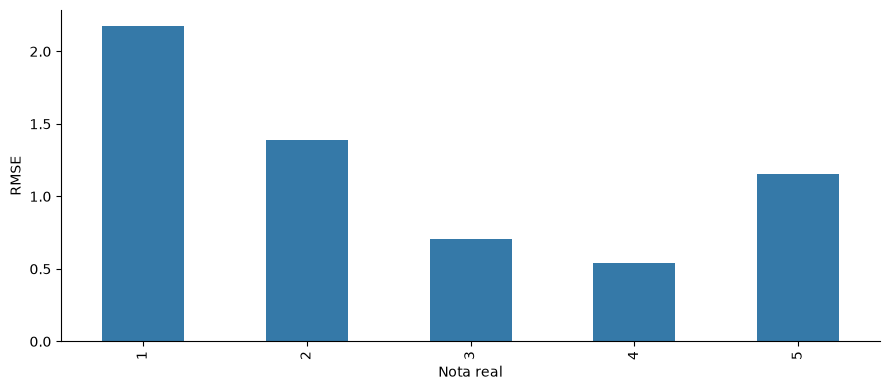

O maior RMSE por nota real ocorre na nota **1**, com **2.176**. O agrupamento por histórico usa cortes fixos de 30 e 100 notas no treino. As diferenças são descritivas: usuários ativos também podem ter preferências diferentes, e não podemos atribuir causalmente o erro à quantidade de histórico.

In [7]:
predictions = pd.read_csv(TABLES / f'{kind}_predictions.csv')
predictions = predictions[predictions.variant=='ajustado'].copy()
predictions['squared_error'] = (predictions.rating-predictions.prediction)**2
by_rating = predictions.groupby('rating').agg(n=('rating','size'),mse=('squared_error','mean'),mean_prediction=('prediction','mean'))
by_rating['rmse'] = np.sqrt(by_rating.mse)
display(save(by_rating.reset_index(),kind+'_error_by_rating'))
predictions['history_group'] = pd.cut(predictions.n_history,[-1,30,100,np.inf],labels=['até 30','31 a 100','mais de 100'])
by_history = predictions.groupby('history_group',observed=True).agg(n=('rating','size'),mse=('squared_error','mean'))
by_history['rmse'] = np.sqrt(by_history.mse)
display(save(by_history.reset_index(),kind+'_error_by_history'))
by_rating.rmse.plot.bar(color='#3579a8'); plt.ylabel('RMSE'); plt.xlabel('Nota real')
plt.tight_layout(); plt.savefig(FIGURES/f'{kind}_errors.png',dpi=150); plt.show()
worst = by_rating.rmse.idxmax()
display(Markdown(f"O maior RMSE por nota real ocorre na nota **{worst}**, com **{by_rating.loc[worst,'rmse']:.3f}**. O agrupamento por histórico usa cortes fixos de 30 e 100 notas no treino. As diferenças são descritivas: usuários ativos também podem ter preferências diferentes, e não podemos atribuir causalmente o erro à quantidade de histórico."))

## 5. Recomendações para os mesmos perfis de atividade
Escolhemos, **no treino do fold 1**, usuários mais próximos dos quantis 10%, 50% e 90% do número de notas; desempate por menor ID. SVD e KNN repetem os mesmos usuários. A configuração deste exemplo é a selecionada internamente no fold 1 e treinada apenas nas 80 mil notas daquele treino.

As tabelas mostram dez recomendações e um recorte de dez notas do histórico, ordenadas por nota e ID; o histórico completo fica salvo. Estes são **exemplos do modelo de avaliação**, não um modelo final treinado em toda a base. Os títulos ajudam a ler as listas, mas não entram na previsão. Escores altos não provam relevância de filmes sem nota observada.

In [8]:
recommendations, history = examples(kind,ratings,items)
display(recommendations)
for activity, g in history.groupby('activity',sort=False):
    print(activity, '— usuário', g.user_id.iloc[0], '— histórico completo:',len(g))
    display(g.sort_values(['rating','item_id'],ascending=[False,True])[['item_id','title','rating']].head(10))
print('Históricos completos salvos em outputs/tables/'+kind+'_example_history.csv')

,activity,user_id,n_history,rank,item_id,score,title
0,baixa,9,19,1,119,5.000000,Maya Lin: A Strong Clear Vision (1994)
1,baixa,9,19,2,1368,5.000000,Mina Tannenbaum (1994)
2,baixa,9,19,3,1449,4.669807,Pather Panchali (1955)
3,baixa,9,19,4,64,4.633179,"Shawshank Redemption, The (1994)"
4,baixa,9,19,5,318,4.583394,Schindler's List (1993)
5,baixa,9,19,6,408,4.567931,"Close Shave, A (1995)"
6,baixa,9,19,7,169,4.484316,"Wrong Trousers, The (1993)"
7,baixa,9,19,8,12,4.483158,"Usual Suspects, The (1995)"
8,baixa,9,19,9,127,4.466388,"Godfather, The (1972)"
9,baixa,9,19,10,427,4.450032,To Kill a Mockingbird (1962)


baixa — usuário 9 — histórico completo: 19


,item_id,title,rating
4,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,5
16,50,Star Wars (1977),5
15,201,Evil Dead II (1987),5
3,286,"English Patient, The (1996)",5
13,371,"Bridges of Madison County, The (1995)",5
18,385,True Lies (1994),5
11,483,Casablanca (1942),5
2,487,Roman Holiday (1953),5
0,691,Dark City (1998),5
17,7,Twelve Monkeys (1995),4


intermediária — usuário 206 — histórico completo: 52


,item_id,title,rating
64,272,Good Will Hunting (1997),5
27,288,Scream (1996),5
19,302,L.A. Confidential (1997),5
65,310,"Rainmaker, The (1997)",5
46,313,Titanic (1997),5
41,315,Apt Pupil (1998),5
40,895,Scream 2 (1997),5
30,258,Contact (1997),4
47,269,"Full Monty, The (1997)",4
26,333,"Game, The (1997)",4


alta — usuário 932 — histórico completo: 198


,item_id,title,rating
211,9,Dead Man Walking (1995),5
229,45,Eat Drink Man Woman (1994),5
249,89,Blade Runner (1982),5
121,98,"Silence of the Lambs, The (1991)",5
170,100,Fargo (1996),5
257,119,Maya Lin: A Strong Clear Vision (1994),5
71,135,2001: A Space Odyssey (1968),5
223,136,Mr. Smith Goes to Washington (1939),5
110,154,Monty Python's Life of Brian (1979),5
247,168,Monty Python and the Holy Grail (1974),5


Históricos completos salvos em outputs/tables/KNN_example_history.csv


In [9]:
for activity,g in recommendations.groupby('activity',sort=False):
    display(Markdown(f"No perfil **{activity}**, o usuário **{g.user_id.iloc[0]}** tem **{g.n_history.iloc[0]}** notas no treino. A lista começa com **{g.iloc[0].title}**, escore **{g.iloc[0].score:.3f}**. Esses escores permitem ordenar candidatos; seu significado é de nota prevista, sem interpretação probabilística."))

No perfil **baixa**, o usuário **9** tem **19** notas no treino. A lista começa com **Maya Lin: A Strong Clear Vision (1994)**, escore **5.000**. Esses escores permitem ordenar candidatos; seu significado é de nota prevista, sem interpretação probabilística.

No perfil **intermediária**, o usuário **206** tem **52** notas no treino. A lista começa com **Mina Tannenbaum (1994)**, escore **4.736**. Esses escores permitem ordenar candidatos; seu significado é de nota prevista, sem interpretação probabilística.

No perfil **alta**, o usuário **932** tem **198** notas no treino. A lista começa com **Usual Suspects, The (1995)**, escore **4.567**. Esses escores permitem ordenar candidatos; seu significado é de nota prevista, sem interpretação probabilística.

## 6. Vizinhos efetivos e fallback
O número de vizinhos varia por par usuário–filme. O resumo abaixo considera avaliações externas com previsão colaborativa bem-sucedida; falhas têm `actual_k` ausente na resposta da biblioteca e ficam na coluna `fallback`. Separadamente, medimos a fração de candidatos de usuários elegíveis que precisaram de fallback para gerar as listas.

In [10]:
display(predictions.actual_k.describe().to_frame('vizinhos_efetivos'))
display(predictions.groupby('fold').agg(fallback=('fallback','mean'),unknown_item=('unknown_item','sum')))
display(Markdown(f"O fallback ocorreu em **{predictions.fallback.mean():.2%}** das notas externas; o número mediano de vizinhos efetivos nas previsões colaborativas foi **{predictions.actual_k.median():.0f}**. A proximidade cosseno utiliza notas brutas, por isso o modelo não corrige diretamente usuários que são sistematicamente mais rigorosos."))

,vizinhos_efetivos
count,99319.000000
mean,52.857892
std,14.439639
min,3.000000
25%,56.000000
50%,60.000000
75%,60.000000
max,60.000000


,fallback,unknown_item
fold,,
1,0.00700,41
2,0.00515,38
3,0.00665,34
4,0.00755,31
5,0.00770,40


O fallback ocorreu em **0.68%** das notas externas; o número mediano de vizinhos efetivos nas previsões colaborativas foi **60**. A proximidade cosseno utiliza notas brutas, por isso o modelo não corrige diretamente usuários que são sistematicamente mais rigorosos.

### Por que o KNN inicial recuperou tão poucos relevantes?
Uma previsão próxima de 5 pode ser construída com poucos vizinhos para um filme raramente avaliado. Como a lista considera todo o catálogo, esses filmes podem ocupar o topo sem aparecer no teste daquele usuário. Conferimos o suporte de treino dos itens recomendados, sem usar este diagnóstico para selecionar parâmetros.

In [11]:
support_rows = []
for algorithm in ['SVD','KNN']:
    top = pd.read_csv(TABLES/f'{algorithm}_top10.csv')
    for (fold,variant),g in top.groupby(['fold','variant']):
        train_ids = np.load(ROOT/f'data/splits/fold_{fold}.npz')['train']
        counts = ratings.iloc[train_ids].item_id.value_counts()
        support = g.item_id.map(counts)
        support_rows.append(dict(model=algorithm,fold=fold,variant=variant,mean_train_support=support.mean(),median_train_support=support.median(),fraction_support_le5=support.le(5).mean(),fraction_score_ge4_99=g.score.ge(4.99).mean()))
support_table = save(pd.DataFrame(support_rows),'top10_training_support')
display(support_table)
display(support_table.groupby(['model','variant'])[['fraction_support_le5','fraction_score_ge4_99']].mean())

,model,fold,variant,mean_train_support,median_train_support,fraction_support_le5,fraction_score_ge4_99
0,SVD,1,ajustado,140.509580,137.0,0.000215,0.051776
1,SVD,1,inicial,158.280517,153.0,0.000000,0.088159
2,SVD,2,ajustado,154.532324,142.0,0.000216,0.054811
3,SVD,2,inicial,160.312757,155.0,0.000000,0.094054
4,SVD,3,ajustado,144.984582,134.0,0.000109,0.057438
5,SVD,3,inicial,160.233659,156.0,0.000109,0.095548
6,SVD,4,ajustado,160.096774,152.0,0.000000,0.048602
7,SVD,4,inicial,167.235591,155.0,0.000000,0.087527
8,SVD,5,ajustado,151.867714,151.0,0.000000,0.049079
9,SVD,5,inicial,164.399675,160.0,0.000000,0.091983


fraction_support_le5  fraction_score_ge4_99
model variant                                              
KNN   ajustado              0.160528               0.089652
      inicial               0.964682               0.962730
SVD   ajustado              0.000108               0.052341
      inicial               0.000022               0.091454

No KNN inicial, entre **82,98% e 99,98%** das recomendações de cada fold recaíram em filmes com até cinco notas no treino. No ajustado, a fração caiu para **8,30% a 29,79%**. A Precisão@10 média passou de **0,0035** para **0,0675**. A seleção interna escolheu `(k=60, min_k=3, min_support=3)` nos cinco folds, exclusivamente pelo RMSE interno.

Isso é compatível com listas iniciais dominadas por notas extremas de filmes com pouco suporte. A comparação em conjunto dos três parâmetros não permite atribuir todo o ganho a uma única mudança. Não alteramos o universo de candidatos nem removemos filmes raros depois de ver o teste.

## 7. Comparação final dos objetivos
Usamos SVD e KNN ajustados exclusivamente na validação interna. Baselines são apresentados somente na métrica apropriada. O traço/NaN na outra métrica significa que aquele baseline não foi definido para essa tarefa, e não desempenho zero.

,model,rmse_mean,rmse_sd,precision10_mean,precision10_sd,n_users_min,n_users_max,fit_seconds_mean,evaluation_seconds_mean
0,KNN,1.013860,0.006158,0.067495,0.012119,921,930,0.312549,5.335656
1,Média global,1.125660,0.007309,NaN,NaN,0,0,0.000416,0.004396
2,Popularidade,NaN,NaN,0.133249,0.003807,921,930,0.001004,0.313915
3,SVD,0.922319,0.006095,0.070650,0.003695,921,930,1.202976,0.556940


,fold,model,rmse,precision10,n_users,fit_seconds,evaluation_seconds,params
0,1,Média global,1.120205,NaN,0,0.000394,0.006412,NaN
1,1,Popularidade,NaN,0.131432,929,0.001148,0.298051,NaN
2,2,Média global,1.117735,NaN,0,0.000416,0.002757,NaN
3,2,Popularidade,NaN,0.137946,925,0.000569,0.296549,NaN
4,3,Média global,1.129373,NaN,0,0.000418,0.004242,NaN
5,3,Popularidade,NaN,0.131270,921,0.001178,0.346798,NaN
6,4,Média global,1.124986,NaN,0,0.000443,0.004335,NaN
7,4,Popularidade,NaN,0.136559,930,0.001067,0.324186,NaN
8,5,Média global,1.135999,NaN,0,0.000407,0.004234,NaN
9,5,Popularidade,NaN,0.129036,923,0.001056,0.303990,NaN


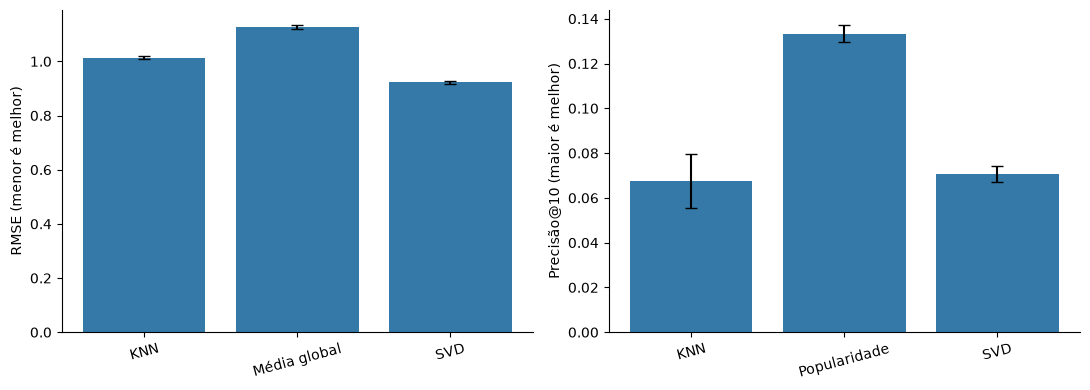

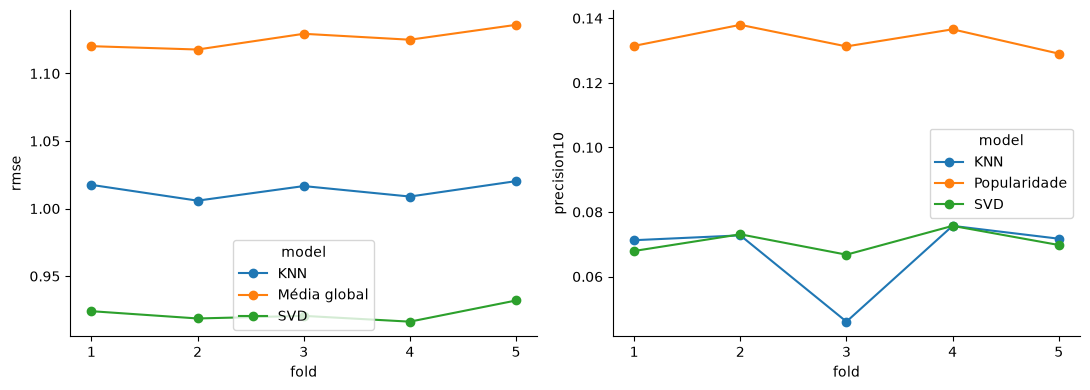

In [12]:
final = comparison()
display(final)
per_fold = pd.read_csv(TABLES/'comparison_folds.csv')
display(per_fold[['fold','model','rmse','precision10','n_users','fit_seconds','evaluation_seconds','params']])
fig,ax=plt.subplots(1,2,figsize=(11,4))
for axis,metric,sd,label in [(ax[0],'rmse_mean','rmse_sd','RMSE (menor é melhor)'),(ax[1],'precision10_mean','precision10_sd','Precisão@10 (maior é melhor)')]:
    g=final.dropna(subset=[metric]); axis.bar(g.model,g[metric],yerr=g[sd],capsize=4,color='#3579a8'); axis.set_ylabel(label); axis.tick_params(axis='x',rotation=15)
plt.tight_layout(); plt.savefig(FIGURES/'comparison.png',dpi=150); plt.show()
fig,ax=plt.subplots(1,2,figsize=(11,4))
for axis,metric in zip(ax,['rmse','precision10']):
    per_fold.pivot(index='fold',columns='model',values=metric).dropna(axis=1,how='all').plot(marker='o',ax=axis)
    axis.set_ylabel(metric); axis.set_xticks(range(1,6))
plt.tight_layout(); plt.savefig(FIGURES/'comparison_folds.png',dpi=150); plt.show()

In [13]:
f=final.set_index('model')
rmse_winner=f.rmse_mean.idxmin(); p_winner=f.precision10_mean.idxmax()
svd=f.loc['SVD']; knn=f.loc['KNN']; pop=f.loc['Popularidade']
display(Markdown(f"**Quem previu melhor?** {rmse_winner}, com RMSE médio **{f.loc[rmse_winner,'rmse_mean']:.4f}**. **Quem recuperou mais relevantes?** {p_winner}, com Precisão@10 média **{f.loc[p_winner,'precision10_mean']:.4f}**. O SVD obteve **{svd.precision10_mean:.4f}**, o KNN **{knn.precision10_mean:.4f}** e a popularidade **{pop.precision10_mean:.4f}**. Comparar cada um à popularidade responde se a personalização trouxe ganho observado neste protocolo, sem transformar diferença média em evidência de superioridade estatística."))
for metric in ['rmse','precision10']:
    pivot=per_fold.pivot(index='fold',columns='model',values=metric).dropna(axis=1,how='all')
    win=pivot.idxmin(axis=1) if metric=='rmse' else pivot.idxmax(axis=1)
    display(Markdown(f"Vencedores descritivos de **{metric}** por fold: " + '; '.join(f"fold {i}: {v}" for i,v in win.items()) + '.'))

**Quem previu melhor?** SVD, com RMSE médio **0.9223**. **Quem recuperou mais relevantes?** Popularidade, com Precisão@10 média **0.1332**. O SVD obteve **0.0707**, o KNN **0.0675** e a popularidade **0.1332**. Comparar cada um à popularidade responde se a personalização trouxe ganho observado neste protocolo, sem transformar diferença média em evidência de superioridade estatística.

Vencedores descritivos de **rmse** por fold: fold 1: SVD; fold 2: SVD; fold 3: SVD; fold 4: SVD; fold 5: SVD.

Vencedores descritivos de **precision10** por fold: fold 1: Popularidade; fold 2: Popularidade; fold 3: Popularidade; fold 4: Popularidade; fold 5: Popularidade.

### Escolha sustentada pelos resultados
Para **prever estrelas**, o **SVD** é a escolha mais adequada neste experimento: RMSE 0,9223, menor que KNN (1,0139) e média global (1,1257), com vantagem descritiva em todos os folds. Para **recuperar relevantes em listas de dez**, a **popularidade** teve o maior resultado: 0,1332, acima de SVD (0,0707) e KNN (0,0675), também nos cinco folds. A personalização não superou o baseline de popularidade.

Entre os modelos personalizados, a diferença média em Precisão@10 é pequena e não define superioridade estatística. O KNN variou mais entre folds (desvio 0,0121, contra 0,0037 do SVD); no fold 4 houve empate. O menor erro do SVD não o transforma no vencedor da tarefa de listas.

O KNN ajusta rapidamente a matriz de similaridades, mas a avaliação dos candidatos custa mais que a do SVD neste código. Vizinhos dão uma interpretação local; fatores e vieses oferecem uma representação compacta. Se o objetivo operacional fosse top 10 sob este protocolo, a popularidade seria o ponto de partida sustentado pelas métricas. Se o objetivo fosse previsão de notas ou uma representação colaborativa, preferiríamos SVD. A escolha permanece limitada ao catálogo histórico e ao desenho offline adotado.

### Adequação, explicabilidade e limites
SVD compartilha informação em fatores e vieses, e sua predição após o ajuste é um produto de vetores; a interpretação desses fatores é indireta. KNN explica uma previsão por usuários vizinhos e suas notas, mas precisa calcular e manter uma matriz de similaridades, além de consultar vizinhos por filme. Popularidade é simples, barata e transparente; precisa ser levada a sério como referencial de recuperação. Os tempos medidos e o desempenho nas duas métricas sustentam a escolha, que depende do objetivo.

Menor RMSE não implica maior Precisão@10: minimizar erro nas notas observadas não equivale a otimizar recuperação no catálogo completo. A Precisão@10 conta acertos no conjunto de dez e **não diferencia a posição desses acertos**. Não usamos nDCG ou outros algoritmos, preservando o escopo da atividade.

A divisão aleatória pode aproveitar preferências futuras em relação à data de uma nota de teste; falta uma avaliação temporal. Os usuários já têm ao menos 20 notas na base original; o cold start real está sub-representado. Candidatos sem nota de teste são desconhecidos, não verdadeiros negativos. A elegibilidade condiciona o resultado a pessoas com relevante observado e não equivale à experiência de todos os usuários.

Diversidade, novidade e serendipidade importam para a experiência, mas não foram medidas. Gêneros nos títulos recomendados não demonstram diversidade. Cinco folds, com treinos sobrepostos e ajuste limitado, não autorizam afirmações de superioridade estatística nem validade universal.

In [14]:
print(manual_checks())
print('Mesmo conjunto de usuários elegíveis por fold: validado em comparison().')
print('Ausência de pares compartilhados e integridade: verificadas em load_data()/folds().')
print('Lote versus Surprise.predict: 200 pares por ajuste externo e exemplos, tolerância 1e-10.')
print('Top 10: sem duplicados ou itens do histórico, com desempate por ID.')

RMSE manual = √2,5; Precisão@10 manual = 2/10; cold start conferido.
Mesmo conjunto de usuários elegíveis por fold: validado em comparison().
Ausência de pares compartilhados e integridade: verificadas em load_data()/folds().
Lote versus Surprise.predict: 200 pares por ajuste externo e exemplos, tolerância 1e-10.
Top 10: sem duplicados ou itens do histórico, com desempate por ID.


## Referências e continuidade
- Material de Victor Coscrato, Laboratório de Estatística Aplicada — 2026/2, páginas 12, 20–24, 27–31 e 33–36.
- [Surprise: SVD](https://surprise.readthedocs.io/en/stable/matrix_factorization.html), [KNN](https://surprise.readthedocs.io/en/stable/knn_inspired.html) e [similaridades](https://surprise.readthedocs.io/en/stable/similarities.html).
- Harper e Konstan (2015), DOI [10.1145/2827872](https://doi.org/10.1145/2827872).

Tabelas, previsões externas, listas, configurações e figuras foram salvas para um relatório posterior. Nesta entrega não geramos HTML.